# Resting EEG Modelling

This notebook starts the machine-learning stage of the resting EEG workflow. The target is binary APOE status: e4 carriers versus non-carriers.

The first modelling attempt compares the full EEG feature set across eyes-closed, eyes-open, and combined resting-state datasets. The combined dataset keeps one row per participant while placing both conditions side by side.


## 1. Setup

The first comparison uses strong regularisation and constrained tree models to reduce overfitting risk. The random seed is fixed at `7` for reproducibility.


In [1]:
from importlib import reload
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import eeg_modelling as em
reload(em)

feature_path = project_root / "data" / "features" / "rest_eeg_features_split.tsv"
model_output_dir = project_root / "reports" / "modelling"
model_output_dir.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 7
TARGET_COL = "APOE_group"
POSITIVE_LABEL = "e4_carrier"

print(f"Feature table: {feature_path}")
print(f"Model outputs: {model_output_dir}")


Feature table: /Users/nataliemarryatt/neurogenetics-ml/data/features/rest_eeg_features_split.tsv
Model outputs: /Users/nataliemarryatt/neurogenetics-ml/reports/modelling


## 2. Load Feature Table

The input table contains one row per subject-condition recording. For most modelling, it is cleaner to reshape this into one row per participant so eyes-open and eyes-closed features stay together.


In [2]:
features_long = pd.read_csv(feature_path, sep="	")

print(f"Long feature table: {features_long.shape[0]} rows x {features_long.shape[1]} columns")
display(features_long[["subject_id", "condition", "split", "cv_fold", TARGET_COL, "PICALM_group"]].head())

print("Rows by condition:")
display(features_long["condition"].value_counts().to_frame("n_rows"))

print("Subjects by split and target:")
display(pd.crosstab(
    features_long.drop_duplicates("subject_id")["split"],
    features_long.drop_duplicates("subject_id")[TARGET_COL],
))



Long feature table: 156 rows x 175 columns


,subject_id,condition,split,cv_fold,APOE_group,PICALM_group
0,sub-08,eyes_closed,test,NaN,non_e4,AA_AG
1,sub-08,eyes_open,test,NaN,non_e4,AA_AG
2,sub-10,eyes_closed,test,NaN,non_e4,AA_AG
3,sub-10,eyes_open,test,NaN,non_e4,AA_AG
4,sub-11,eyes_closed,test,NaN,non_e4,AA_AG


Rows by condition:


,n_rows
condition,
eyes_closed,78
eyes_open,78


Subjects by split and target:


APOE_group,e4_carrier,non_e4
split,,
test,10,6
train,37,25


## 3. Investigate Full Feature Set In Eyes-Open, Eyes-Closed And Combined Datasets

This first model comparison uses the full set of EEG features derived from each resting-state view: eyes-open only, eyes-closed only, and a combined dataset containing both conditions side by side.

The main concern is overfitting because the number of features is larger than the number of training participants. To make this first pass more conservative, logistic regression uses strong L2 regularisation. Random forest and XGBoost are included as nonlinear tree-based comparisons, but their depth is deliberately restricted.

The compared models are:

- logistic regression with strong L2 regularisation
- random forest
- XGBoost gradient boosting


### 3.1 Create Subject-Level Modelling Datasets

Each dataset has one row per participant. The combined dataset keeps eyes-open and eyes-closed features as separate columns for the same subject, rather than treating them as independent rows.


In [3]:
model_datasets, model_feature_cols = em.make_subject_level_datasets(features_long)

display(em.dataset_summary(model_datasets, model_feature_cols))


,dataset,n_subjects,n_train_subjects,n_test_subjects,n_features
0,eyes_closed,78,62,16,161
1,eyes_open,78,62,16,161
2,combined,78,62,16,322


### 3.2 Define Models

All models are evaluated using the same subject-level train/test split. Logistic regression uses stronger L2 regularisation than the default setting. The tree models are constrained to reduce overfitting in this small sample.


In [4]:
models = em.make_first_attempt_models(random_state=RANDOM_STATE)
list(models)


['logistic_regression_l2_c0.1', 'random_forest', 'xgboost_gradient_boosting']

### 3.3 Cross-Validated And Held-Out Model Comparison

Models are compared using balanced accuracy. Cross-validation is performed only within the training subjects using the `cv_fold` labels, then each model is evaluated once on the held-out test subjects.


In [5]:
model_comparison, _ = em.evaluate_cv_and_test(
    model_datasets,
    model_feature_cols,
    models,
    target_col=TARGET_COL,
    positive_label=POSITIVE_LABEL,
)

model_comparison.to_csv(model_output_dir / "first_attempt_full_feature_balanced_accuracy.tsv", sep="	", index=False)
display(model_comparison)


/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

,dataset,model,n_subjects_train,n_subjects_test,n_features_input,cv_balanced_accuracy_mean,cv_balanced_accuracy_sd,test_balanced_accuracy
3,eyes_open,logistic_regression_l2_c0.1,62,16,161,0.630520,0.084492,0.266667
4,eyes_open,random_forest,62,16,161,0.609865,0.025805,0.533333
5,eyes_open,xgboost_gradient_boosting,62,16,161,0.505698,0.019213,0.500000
7,combined,random_forest,62,16,322,0.472044,0.039909,0.583333
2,eyes_closed,xgboost_gradient_boosting,62,16,161,0.468305,0.113712,0.533333
8,combined,xgboost_gradient_boosting,62,16,322,0.446403,0.067843,0.583333
1,eyes_closed,random_forest,62,16,161,0.420940,0.052882,0.450000
6,combined,logistic_regression_l2_c0.1,62,16,322,0.411859,0.026720,0.500000
0,eyes_closed,logistic_regression_l2_c0.1,62,16,161,0.407942,0.048307,0.400000


### 3.4 Plot CV And Test-Fold Balanced Accuracy

Balanced accuracy of 0.50 is chance-level performance for this binary carrier/non-carrier problem. In this first full-feature comparison, the highest cross-validated result does not translate well to the held-out test fold, which is a clear warning sign for overfitting or split instability. Even with strong L2 regularisation, the full feature table may still contain too many predictors relative to the number of participants.

Rather than continuing to tune the same high-dimensional model, the next step is to break the analysis down into eyes-open versus eyes-closed recordings and into specific EEG feature families.

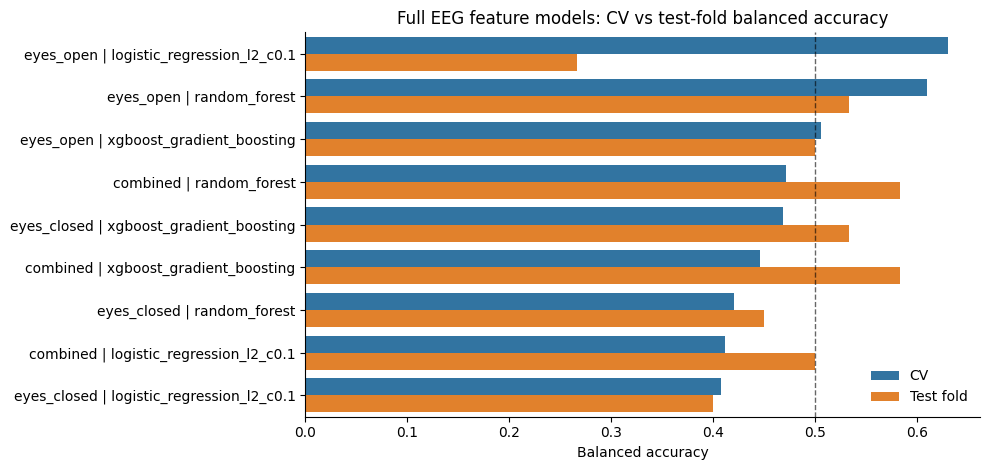

In [6]:
fig = em.plot_cv_test_balanced_accuracy(
    model_comparison,
    model_output_dir / "first_attempt_full_feature_balanced_accuracy.png",
    title="Full EEG feature models: CV vs test-fold balanced accuracy",
)
plt.show()


## 4. Compare Feature Families By Resting Condition

This section tests whether specific feature families perform more consistently than the full feature table. Eyes-open and eyes-closed data are modelled separately, using the same three first-attempt models: logistic regression with strong L2 regularisation, random forest, and XGBoost.

This keeps the comparison interpretable: if one feature family performs better than chance more consistently, it becomes a stronger candidate for closer inspection in the next modelling iteration.

In [7]:
subtype_results = em.evaluate_feature_subtypes(
    model_datasets,
    model_feature_cols,
    models,
    datasets_to_include=("eyes_open", "eyes_closed"),
    target_col=TARGET_COL,
    positive_label=POSITIVE_LABEL,
)

subtype_results.to_csv(model_output_dir / "feature_subtype_balanced_accuracy.tsv", sep="	", index=False)
display(subtype_results)

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

...

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

,dataset,feature_subtype,model,n_subjects_train,n_subjects_test,n_features_input,cv_balanced_accuracy_mean,cv_balanced_accuracy_sd,test_balanced_accuracy
19,eyes_closed,aperiodic_periodic,random_forest,62,16,6,0.446225,0.097888,0.416667
18,eyes_closed,aperiodic_periodic,logistic_regression_l2_c0.1,62,16,6,0.537571,0.052147,0.450000
20,eyes_closed,aperiodic_periodic,xgboost_gradient_boosting,62,16,6,0.548077,0.128051,0.516667
25,eyes_closed,connectivity_graph,random_forest,62,16,60,0.359509,0.044649,0.533333
24,eyes_closed,connectivity_graph,logistic_regression_l2_c0.1,62,16,60,0.410256,0.110712,0.616667
26,eyes_closed,connectivity_graph,xgboost_gradient_boosting,62,16,60,0.420050,0.078807,0.550000
29,eyes_closed,microstate,xgboost_gradient_boosting,62,16,21,0.443020,0.065271,0.383333
27,eyes_closed,microstate,logistic_regression_l2_c0.1,62,16,21,0.496083,0.019855,0.683333
28,eyes_closed,microstate,random_forest,62,16,21,0.517094,0.046527,0.383333
17,eyes_closed,spectral,xgboost_gradient_boosting,62,16,61,0.466168,0.064259,0.333333


## 5. Plot Feature Family Results

Each plot shows cross-validated balanced accuracy on the left and held-out test-fold balanced accuracy on the right. Within each feature family, the three models are shown side by side. The dashed line marks chance-level performance.

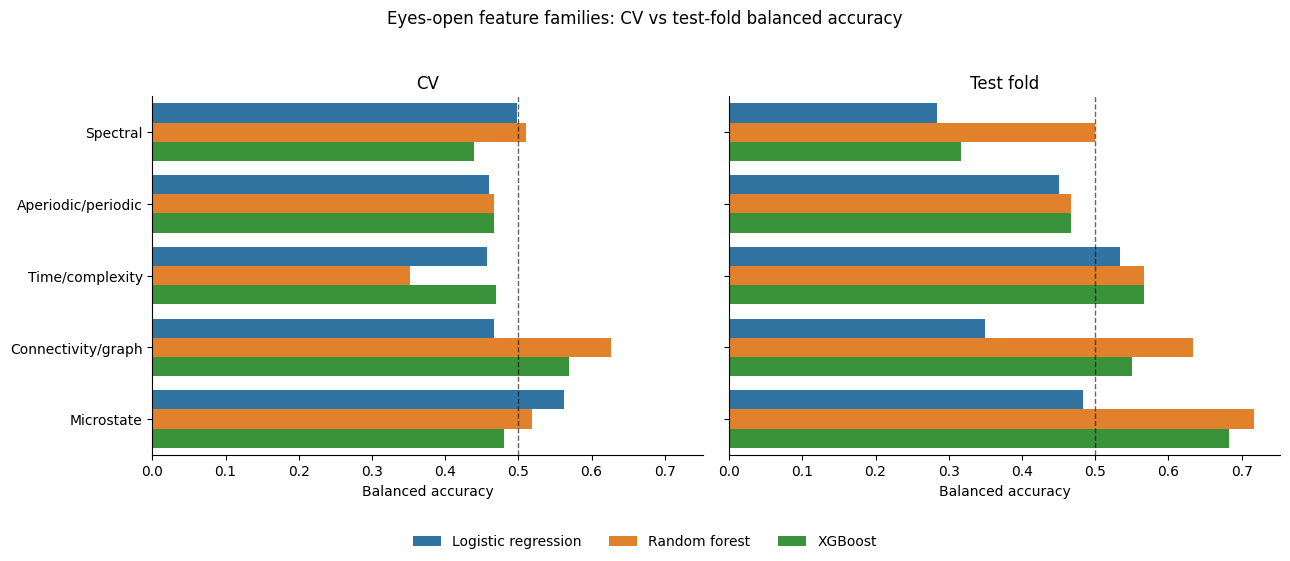

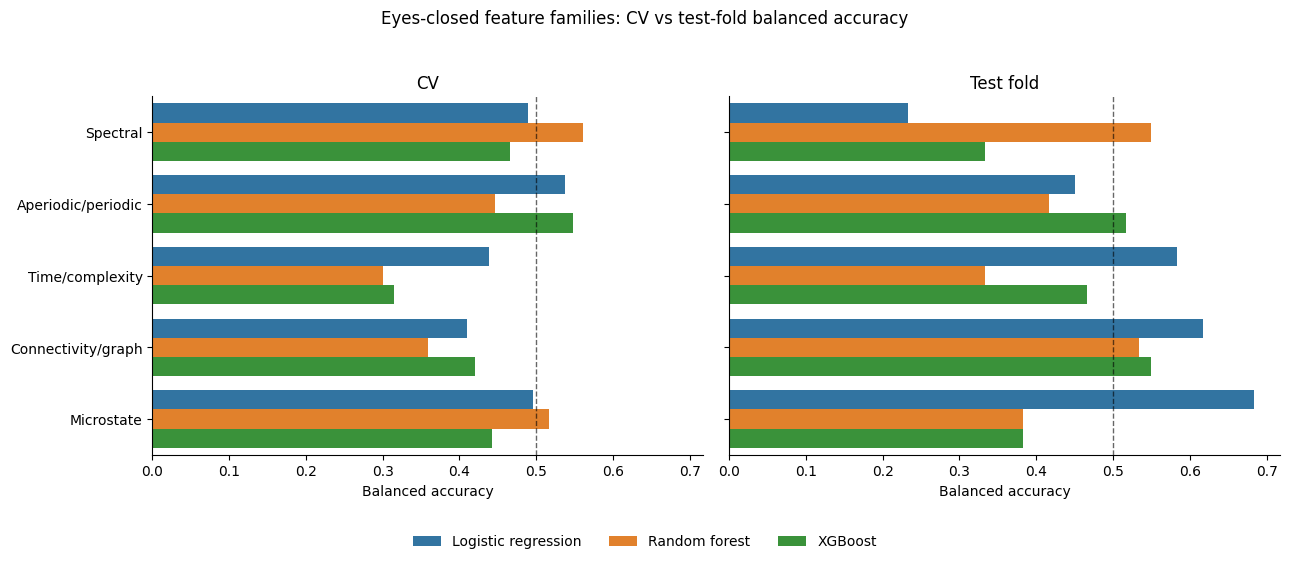

In [8]:
fig = em.plot_feature_subtype_results(
    subtype_results,
    dataset="eyes_open",
    output_path=model_output_dir / "feature_subtypes_eyes_open_balanced_accuracy.png",
    title="Eyes-open feature families: CV vs test-fold balanced accuracy",
)
plt.show()

fig = em.plot_feature_subtype_results(
    subtype_results,
    dataset="eyes_closed",
    output_path=model_output_dir / "feature_subtypes_eyes_closed_balanced_accuracy.png",
    title="Eyes-closed feature families: CV vs test-fold balanced accuracy",
)
plt.show()

## 6. Inspect Strongest Random Forest Views

The feature-family comparison suggests three Random Forest views are worth inspecting more closely: eyes-open connectivity/graph features, eyes-open microstate features, and eyes-closed spectral features. These are not final selected biomarkers; they are the strongest exploratory views from the current CV/test comparison.

Feature importance is calculated after fitting each Random Forest model on the training subjects only. This gives a first look at which variables the model is using, while keeping the held-out test fold separate.

In [9]:
selected_rf_views = [
    {
        "dataset": "eyes_open",
        "feature_subtype": "connectivity_graph",
        "view_label": "Eyes-open connectivity/graph RF",
    },
    {
        "dataset": "eyes_open",
        "feature_subtype": "microstate",
        "view_label": "Eyes-open microstate RF",
    },
    {
        "dataset": "eyes_closed",
        "feature_subtype": "spectral",
        "view_label": "Eyes-closed spectral RF",
    },
]

rf_feature_importances = em.random_forest_feature_importances(
    model_datasets,
    model_feature_cols,
    selected_rf_views,
    random_state=RANDOM_STATE,
    target_col=TARGET_COL,
    positive_label=POSITIVE_LABEL,
)

rf_feature_importances.to_csv(model_output_dir / "selected_random_forest_feature_importances.tsv", sep="	", index=False)
display(rf_feature_importances.loc[rf_feature_importances["rank_within_view"] <= 10])

,view,dataset,feature_subtype,feature,importance,rank_within_view
100,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_theta_temporal,0.056933,1
94,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_theta_global,0.054752,2
104,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_theta_occipital,0.052825,3
86,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_delta_central,0.051203,4
88,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_delta_temporal,0.048086,5
114,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_alpha_parietal,0.044115,6
106,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_alpha_global,0.038926,7
98,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_theta_central,0.038489,8
102,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_theta_parietal,0.036630,9
96,Eyes-closed spectral RF,eyes_closed,spectral,power_rel_theta_frontal,0.035411,10


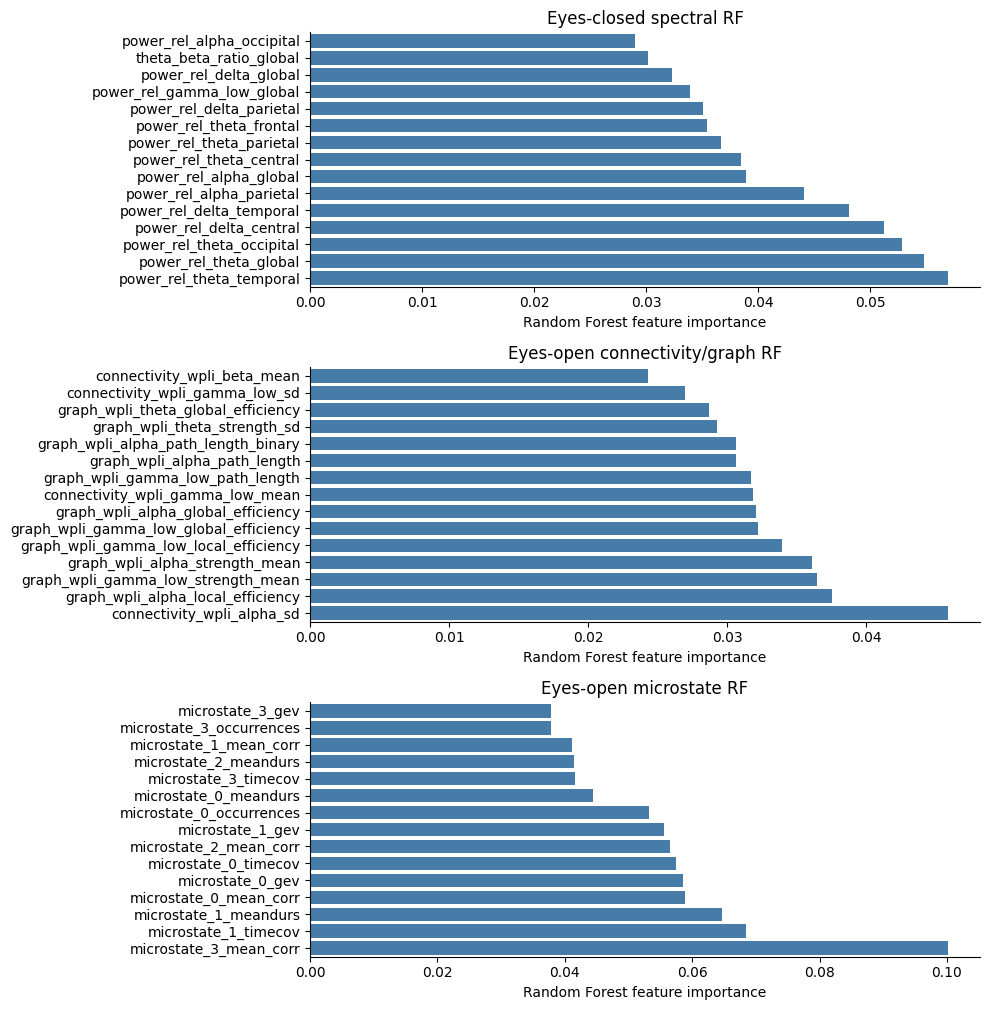

In [10]:
fig = em.plot_top_feature_importances(
    rf_feature_importances,
    output_path=model_output_dir / "selected_random_forest_feature_importances.png",
    top_n=15,
)
plt.show()

## 7. Test A Three-View Ensemble

This ensemble tests whether the three strongest Random Forest views provide complementary information. Each view is fitted separately, then the predicted APOE carrier probabilities are averaged across the three views. A final class prediction is made using a probability threshold of 0.50.

This is still exploratory. The main question is whether combining these views improves cross-validated balanced accuracy, not just the held-out test fold.

In [11]:
ensemble_summary, ensemble_predictions = em.evaluate_three_view_probability_ensemble(
    model_datasets,
    model_feature_cols,
    selected_rf_views,
    random_state=RANDOM_STATE,
    target_col=TARGET_COL,
    positive_label=POSITIVE_LABEL,
)

ensemble_summary.to_csv(model_output_dir / "three_view_random_forest_ensemble_summary.tsv", sep="	", index=False)
ensemble_predictions.to_csv(model_output_dir / "three_view_random_forest_ensemble_predictions.tsv", sep="	", index=False)
display(ensemble_summary)

,model,views,n_subjects_train,n_subjects_test,cv_balanced_accuracy,test_balanced_accuracy
0,three_view_random_forest_probability_ensemble,Eyes-open connectivity/graph RF + Eyes-open mi...,62,16,0.578378,0.55


## 8. Ensemble Result

The three-view ensemble is useful as a check for complementary information, but in this run it does not improve on the strongest single view. The ensemble achieved cross-validated balanced accuracy of approximately 0.58 and test-fold balanced accuracy of 0.55, while the eyes-open connectivity/graph Random Forest had stronger performance in both CV and the held-out test fold.

This suggests that the selected views are not yet adding enough independent signal to justify an ensemble, or that the apparent test-fold gains are unstable because the held-out test set is small. For now, the eyes-open connectivity/graph feature set is the clearest candidate for closer investigation.


## 9. Single Random Forest With Eyes-Open Connectivity And Microstate Features

The ensemble keeps each view as a separate model and averages their predicted probabilities. A simpler alternative is to combine the eyes-open connectivity/graph and microstate features into one feature table, then fit a single Random Forest. This tests whether the model can use interactions across these two eyes-open feature families directly.

In [12]:
eo_connectivity_microstate_rf, eo_connectivity_microstate_importances = em.evaluate_random_forest_feature_combo(
    model_datasets,
    model_feature_cols,
    dataset_name="eyes_open",
    feature_subtypes=("connectivity_graph", "microstate"),
    combo_label="eyes_open_connectivity_graph_plus_microstate",
    random_state=RANDOM_STATE,
    target_col=TARGET_COL,
    positive_label=POSITIVE_LABEL,
)

eo_connectivity_microstate_rf.to_csv(
    model_output_dir / "eyes_open_connectivity_microstate_random_forest_summary.tsv",
    sep="	",
    index=False,
)
eo_connectivity_microstate_importances.to_csv(
    model_output_dir / "eyes_open_connectivity_microstate_random_forest_importances.tsv",
    sep="	",
    index=False,
)

display(eo_connectivity_microstate_rf)
display(eo_connectivity_microstate_importances.head(20))

,dataset,feature_set,model,n_subjects_train,n_subjects_test,n_features_input,cv_balanced_accuracy_mean,cv_balanced_accuracy_sd,test_balanced_accuracy
0,eyes_open,eyes_open_connectivity_graph_plus_microstate,random_forest,62,16,81,0.719907,0.115694,0.683333


,feature_set,feature,importance,rank
75,eyes_open_connectivity_graph_plus_microstate,microstate_3_mean_corr,0.040155,1
50,eyes_open_connectivity_graph_plus_microstate,graph_wpli_gamma_low_strength_mean,0.039580,2
16,eyes_open_connectivity_graph_plus_microstate,connectivity_wpli_alpha_sd,0.037428,3
25,eyes_open_connectivity_graph_plus_microstate,graph_wpli_alpha_local_efficiency,0.028177,4
45,eyes_open_connectivity_graph_plus_microstate,connectivity_wpli_gamma_low_mean,0.026425,5
55,eyes_open_connectivity_graph_plus_microstate,graph_wpli_gamma_low_local_efficiency,0.025505,6
20,eyes_open_connectivity_graph_plus_microstate,graph_wpli_alpha_strength_mean,0.025423,7
63,eyes_open_connectivity_graph_plus_microstate,microstate_0_timecov,0.024883,8
53,eyes_open_connectivity_graph_plus_microstate,graph_wpli_gamma_low_path_length,0.024877,9
9,eyes_open_connectivity_graph_plus_microstate,graph_wpli_theta_global_efficiency,0.024119,10


## 10. Held-Out Test Metrics For The Top Model

The top current model is the single Random Forest using eyes-open connectivity/graph and microstate features. Here, I calculate the main held-out test-fold classification metrics: accuracy, balanced accuracy, sensitivity/recall, specificity, precision, F1, ROC-AUC and the confusion-matrix counts.

These metrics should still be interpreted cautiously because the held-out test fold contains only 16 participants.

In [13]:
top_model_metrics, top_model_predictions = em.evaluate_random_forest_feature_combo_with_metrics(
    model_datasets,
    model_feature_cols,
    dataset_name="eyes_open",
    feature_subtypes=("connectivity_graph", "microstate"),
    combo_label="eyes_open_connectivity_graph_plus_microstate",
    random_state=RANDOM_STATE,
    target_col=TARGET_COL,
    positive_label=POSITIVE_LABEL,
)

top_model_metrics.to_csv(
    model_output_dir / "top_model_eyes_open_connectivity_microstate_rf_metrics.tsv",
    sep="	",
    index=False,
)
top_model_predictions.to_csv(
    model_output_dir / "top_model_eyes_open_connectivity_microstate_rf_predictions.tsv",
    sep="	",
    index=False,
)

display(top_model_metrics.T.rename(columns={0: "value"}))
display(top_model_predictions)

,value
dataset,eyes_open
feature_set,eyes_open_connectivity_graph_plus_microstate
model,random_forest
n_subjects_train,62
n_subjects_test,16
n_features_input,81
accuracy,0.6875
balanced_accuracy,0.683333
sensitivity_recall,0.7
specificity,0.666667


,subject_id,APOE_group,true_label,predicted_label,predicted_probability
0,sub-08,non_e4,0,0,0.433864
1,sub-10,non_e4,0,0,0.450210
2,sub-11,non_e4,0,0,0.372170
3,sub-24,non_e4,0,1,0.582906
4,sub-29,non_e4,0,0,0.384663
5,sub-31,non_e4,0,1,0.540443
6,sub-35,e4_carrier,1,1,0.631809
7,sub-36,e4_carrier,1,1,0.647901
8,sub-40,e4_carrier,1,1,0.500938
9,sub-46,e4_carrier,1,0,0.477203


## Notes

This notebook starts with binary APOE carrier prediction using the full EEG feature set across eyes-open, eyes-closed, and combined resting-state datasets. The main metric is balanced accuracy, which is more appropriate than raw accuracy when the carrier and non-carrier groups are uneven.

The first full-feature attempt should be treated as an exploratory diagnostic rather than a final model. The next modelling step is to use the condition-specific feature-family results to decide which smaller, more interpretable feature sets are worth investigating further.